# <font color="steelblue">200. Variables aleatorias continuas</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**


**Fecha última edición**: 10/05/2025

**Licencia**: <small><a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a><br /></small>

No olvides hacer una copia si deseas utilizarlo. Al usar estos contenidos, aceptas nuestros términos de uso y nuestra política de privacidad.

## <font color='steelblue'>Introducción</font>

**Descripción:** Las variables aleatorias continuas son aquellas cuyos valores pueden tomar cualquier número dentro de un rango continuo. A diferencia de las variables aleatorias discretas, que toman valores específicos, las variables aleatorias continuas tienen una densidad de probabilidad asociada, que describe la probabilidad de que la variable caiga dentro de un intervalo determinado.

La distribución uniforme es una de las distribuciones más simples y comunes. En esta distribución, todos los valores dentro de un intervalo tienen la misma probabilidad de ocurrencia. Es decir, la densidad de probabilidad es constante dentro del intervalo y cero fuera de él.

La distribución exponencial describe la ocurrencia de eventos en un intervalo de tiempo continuo, donde la tasa de ocurrencia de eventos se mantiene constante. Esta distribución es ampliamente utilizada en el modelado de tiempos de espera y en la teoría de colas.

La distribución normal, también conocida como distribución gaussiana, es una de las distribuciones más importantes en estadística. Se caracteriza por tener una forma de campana simétrica y está completamente determinada por su media y desviación estándar. Muchos fenómenos naturales y sociales siguen aproximadamente esta distribución, lo que hace que sea ampliamente utilizada en análisis y predicciones.

Además de las distribuciones mencionadas, existen numerosas distribuciones que se utilizan para modelar diferentes tipos de fenómenos, como la Gamma o la Beta. Cada una de estas distribuciones tiene características y propiedades específicas que las hacen adecuadas para diferentes situaciones.


## <font color='steelblue'> Objetivos de aprendizaje

* Comprender la definición de una variable aleatoria continua y su relación con la densidad de probabilidad para poder utilizarla en la resolución de problemas y cálculos estadísticos.

* Identificar la distribución Uniforme como un modelo de probabilidad con igual probabilidad de ocurrencia para cualquier valor dentro del intervalo definido.

* Reconocer la distribución Exponencial como un modelo de probabilidad que describe el tiempo de espera entre eventos.

* Entender la distribución Normal como un modelo de probabilidad con una forma de campana simétrica.

* Características y propiedades para poder aplicar la distribución normal estandarizada en distintos escenarios y cálculos estadísticos.

* Estandarización de cualquier distribución normal para poder trabajar con una distribución más sencilla y de propiedades conocidas.

* Saber cómo interpretar los resultados obtenidos con los percentiles de la distribución normal, para poder analizar y comparar datos estadísticos.

* Aplicar el teorema central del límite en diferentes situaciones experimentales.

## <font color='steelblue'> Contenidos </font>

1. Variables aleatorias continuas y la densidad
1. Distribución Uniforme
1. Distribución Exponencial
1. Distribución Normal

## <font color='steelblue'> 1. Variables aleatorias continuas y la densidad

En este cuaderno vamos a desarrollar métodos para trabajar con *variables aleatorias* que pueden tomar valores que se encuentran en un intervalo de números. Si recordamos del cuaderno anterior, las *variables aleatorias discretas* solo podían tomar un número contable de valores posibles. En cambio, las **variables aleatorias continuas** toman valores de un intervalo de valores finito o infinito, pero aun siendo finito tiene un número incontable de números. Esto es así porque si consideramos $X$ como la *variable aleatoria continua*, todos sus posibles valores $x$ se encuentran dentro de la recta de los números reales: $x \in \mathbb R$. Así pues, necesitaremos desarrollar nuevas herramientas para poder trabajar con este tipo de variables. La parte buena es que muchos de los resultados que utilizamos para las *variables aleatorias discretas* guardan una similitud con las *variables aleatorias continuas*.

Antes de continuar, vamos a preparar el entorno que necesitaremos para trabajar con **Python**, ya que con estas variables vamos a utilizarlo bastante. Primero utilizamos el comando mágico de `matplotlib`, luego importamos `NumPy`, `Matplotlib` y  `Scipy` con sus abreviaturas correspondientes.

In [1]:
# Comando mágico de matplotlib
%matplotlib inline

# Importamos las librerías que necesitamos
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

### <font color='steelblue'> Función de densidad

En el caso de las varaibles aleatorias contínuas no disponemos de la función de masa de probabildiad y debemos introducir un nuevo concepto para poder evaluar las probabildiades de interés.

La **función de densidad de probabilidad**, o *densidad*, es una función $f$ *no negativa* en el la recta real de forma que:

$$\int_{-\infty}^{\infty} f(x)dx = 1$$

Si no sabemos nada o casi nada sobre integrales, no tenemos que preocuparnos por esto, más adelante vamos a ver cómo calcularlas con la ayuda de **Python**.

Veamos ahora un ejemplo de cómo se puede ver una *función de densidad de probabilidad*. Consideramos la siguiente *función de densidad* $f$:

$$
f(x) = \left\lbrace\begin{array}{l} 0,~~~~~~~~~~~~~~~~~~~si~x \leq 0 \\ 6x \cdot (1-x),~~si~0 \lt x \lt 1 \\ 0,~~~~~~~~~~~~~~~~~~~si~x \geq 1 \end{array}\right.
$$

Para quien sepa, podéis comprobar que la integral de esta función es 1, pero ya veremos un poco más adelante cómo calcularlo. A continuación, mostramos el gráfico de nuestra función $f$.

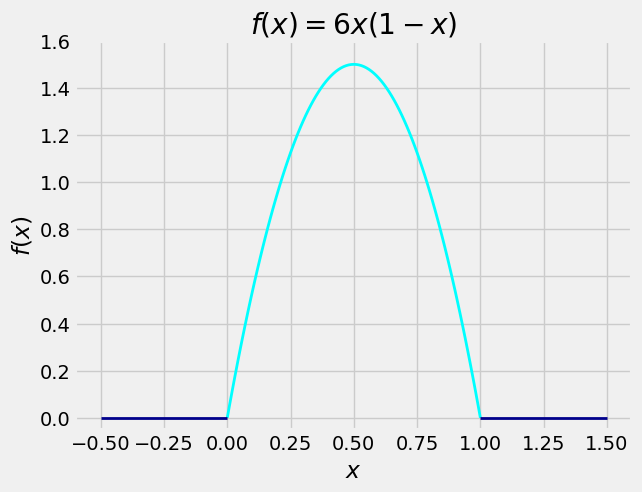

In [2]:
#@title <font color="steelblue" size="+1"> Gráfico función de densidad { display-mode: "form" }

plt.style.use('fivethirtyeight')

def f(y):
    return 6*y*(1-y)

valores_x = np.arange(0, 1.01, 0.01)
plt.plot(valores_x, f(valores_x), color='cyan', lw=2)
plt.plot([-0.5, 0], [0, 0], color='darkblue', lw=2)
plt.plot([1, 1.5], [0, 0], color='darkblue', lw=2)
plt.ylim(-0.05, 1.6)
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.title("$f(x) = 6x(1-x)$")
plt.show()

La *función de densidad* es la que aparece de color cian (el azul más claro) y sitúa todas las probabilidades en el intervalo $(0, 1)$.

Debemos diferenciar entre *densidad* y *probabilidad*, ya que no significan lo mismo. Para ello solo hay que fijarse en la anterior *función de densidad*: si le damos el valor $0.5$ a $x$, obtenemos que $f(0.5) = 1.5$, siendo más grande que $1$. Sabemos que el valor máximo de una probabilidad es $1$, por lo tanto, ya hemos demostrado que los valores de nuestra función $f$ no son probabilidades. Si la *función de densidad* es positiva (por encima del *eje x*), entonces solo se mostrará esa parte, suponiendo que el resto vale $0$. Quedándonos así la función $f(x) = 6x \cdot (1-x)$ para $0 \lt x \lt 1$ para representar.

### <font color='steelblue'> Función de distribución

Igual que ocurria en las variables aleatorias de tipo discreto se define la función de distribución $F$ asociada a la función de densidad $f$ como:

$$F(a) = P(X \leq a) = \int_{-\infty}^{a} f(x)dx$$

y de forma inmediata podemos calcular la probabilidad de un intervalo $(a, b)$ (siendo $a \lt b$) como:

$$
P(a \lt X \leq b) = F(b) - F(a)= \int_a^b f(x) dx
$$

Esta probabilidad además conincide con el **área de probabilidad** o **área bajo la curva** que delimita el intervalo $(a,b)$ sobre la función de densidad $f$. A continuación mostramos diferentes situaciones donde podemos evalaur probabilidades utilizando la función de distribución y las herramientas que nos proporciona **Python**.

En pirmer luagr estamos interesados en conocer la probabilidad del intervalo $(0.5, 0.7)$ para la función de densidad que hemos definido anteriormente. Dicha probabilidad viene dada por:

$$P(0.5 \lt X \lt 0.7) = \int_{0.5}^{0.7} f(x) dx$$

Visualmente la probabildiad solicitada es:

<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-4042994312.py:8: SyntaxWarning: invalid escape sequence '\l'
  plt.title('Área de probabilidad = $P(0.5 < X \leq 0.7)$');


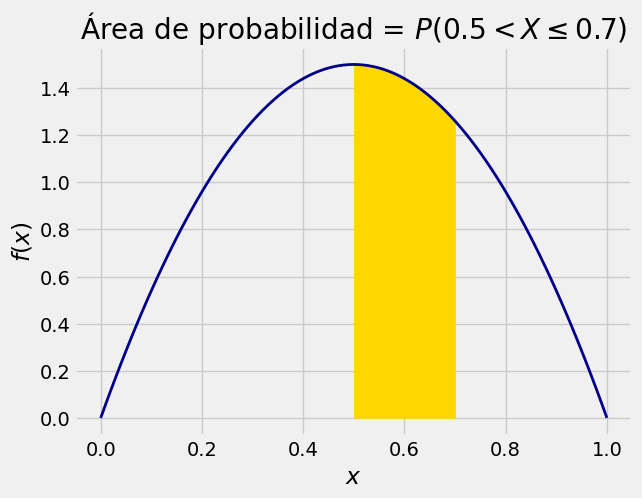

In [3]:
#@title <font color="steelblue" size="+1"> Gráfico área de probabilidad { display-mode: "form" }

plt.plot(valores_x, f(valores_x), color='darkblue', lw=2)
w = np.arange(0.5, 0.701, 0.01)
plt.fill_between(w, f(w), color='gold')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.title('Área de probabilidad = $P(0.5 < X \leq 0.7)$');

Numéricamente tendremos que resolver:

$$
P(0.5 \lt X \leq 0.7) = \int_{0.5}^{0.7} 6x \cdot (1-x) dx
$$

Si no sabes nada sobre integrar, no te preocupes, es el momento de explicar cómo resolver *integrales definidas* con **Python**. Nos vamos a ayudar del módulo de este programa llamado *SymPy*, que hace álgebra, cálculo y muchas otras matemáticas simbólicas. Para declarar variables en las *funciones de densidad* y que no las tome como variables normales,  instalaremos el módulo `prob140`. Tanto de `sympy` como de `prob140`, importaremos todas las funciones. Para ello escribiremos `from modulo import *`. Vamos a realizar lo que acabamos de indicar, con el código mágico `%%capture` al inicio para que no se muestren mensajes innecesarios al instalar el paquete.

In [4]:
# No mostramos mensajes innecesarios
%%capture
# instalamos el módulo prob140
!pip install prob140
# importamos todas las funciones de prob140 y la librería SymPy
from prob140 import *
from sympy import *

Veamos como definir nuestra función de densidad:

In [5]:
# Función para configurar la salida
init_printing()
# Declaramos la variable x como simbólica para que pueda salir por pantalla y podamos integrar sobre ella
declare('x', interval=(0, 1))
# Creamos la función de densidad con la variable x ya declarada previamente
funcion_densidad = 6*x * (1-x)
funcion_densidad

6⋅x⋅(1 - x)

Ahora utilizamos la función `Integral` del módulo `sympy` para calcular nuestra integral. Dicha función tiene 2 argumentos:

* El primero será la *función de densidad* que hemos definido antes.
* El segundo será una tupla con 3 valores:
  * la variable sobre la que integraremos, que suele ser la declarada como simbólica (`x` en este caso),
  * el límite inferior de nuestra integral (`0.5`)
  * y el límite superior en la que está definida la integral (`0.7`).

In [6]:
# Generamos y mostramos la integral definida
integral_definida = Integral(funcion_densidad, (x, 0.5, 0.7))
integral_definida

0.7               
 ⌠                
 ⎮  6⋅x⋅(1 - x) dx
 ⌡                
0.5               

Ahora simplemente calculamos la integral utilizzando la extensión `.doit()` sobre nuestra variable `integral_definida`.

In [7]:
# Valor del área bajo la curva
integral_definida.doit()

0.284000000000000

Ahora podemos responder a la pregunta de la probabilidad de que nuestra variable $X$ se encuentre entre $0.5$ y $0.7$, siendo esta $P(0.5 \lt X \leq 0.7) = 0.284$.

Estamos interesados ahora en calcular la *probabilidad acumulada* para un valor determinado de la variable $X$. Por ejemplo, le daremos el valor $0.7$, con lo que tendremos que calcular $F_X(0.7) = P(X \leq 0.7)$. Veamos el resultado:

In [8]:
# Generamos y mostramos la integral definida
integral_definida2 = Integral(funcion_densidad, (x, 0, 0.7))
integral_definida2

0.7               
 ⌠                
 ⎮  6⋅x⋅(1 - x) dx
 ⌡                
 0                

Una vez tenemos esto, solo falta aplicar la extensión `doit()` para que nos devuelva el valor que queremos.

In [9]:
# Valor del área bajo la curva
integral_definida2.doit()

0.784000000000000

La solución gráfica viene dada por:

<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-3878479556.py:8: SyntaxWarning: invalid escape sequence '\l'
  plt.title('Área bajo la curva: $F_X(0.7) = P_X(k \leq 0.7)$');


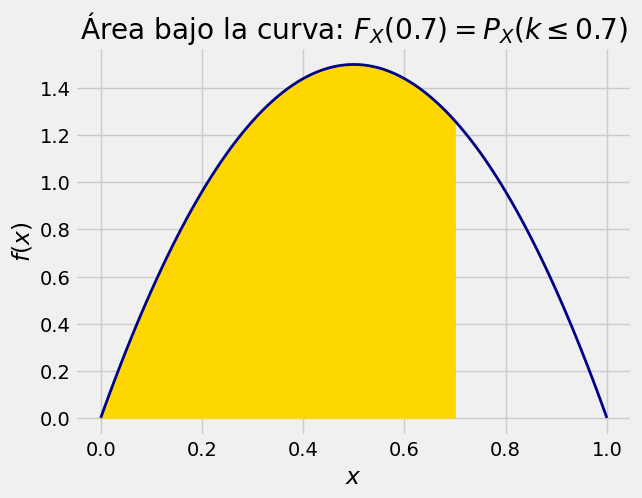

In [10]:
#@title <font color="steelblue" size="+1"> Gráfico de la probabilidad acumulada para x=0.7 { display-mode: "form" }
%matplotlib inline
plt.plot(valores_x, f(valores_x), color='darkblue', lw=2)
w = np.arange(0, 0.701, 0.01)
plt.fill_between(w, f(w), color='gold')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.title('Área bajo la curva: $F_X(0.7) = P_X(k \leq 0.7)$');

### <font color='steelblue'> Esperanza y Varianza

Se define la esperanza de una variable aleatoria de tipo contínuo como:

$$E(X) = \int_{-\infty}^{\infty} xf(x)dx$$

y la varianza como:

$$V(X) = \int_{-\infty}^{\infty} (x-E(x))^2f(x)dx$$

De nuevo la desviación típica se obtiene como la raíz cuadrada de la varianza.

A continuación vamos a presentar las variables aleatorias de tipo continuo más conocidas.

### <font color='steelblue'> Calculo de probabildiades

Como ya hicimos en el cuaderno anterior vamos a presentar las diferetes opciones de cálculo de probabilidades para variables aleatorias de tipo contínuo:

| Situación| Calculo|
|---------|----------|
|P(X<=a)| F(a) |
|P(X>=a)| 1-F(a)|
|P(X<x)| F(a)|
|P(X>a)| 1-F(a)|
|P(a<X<b)| F(b)-F(a)|
|P(a<=X<b)| F(b)-F(a)|
|P(a<X<=b)| F(b)-F(a)|
|P(a<=X<=b)| F(b)-F(a)|

## <font color='steelblue'> 2. Distribución Uniforme

Como vimos en el cuaderno anterior, existen funciones que nos ayudan a ver el comportamiento las *variables aleatorias*. Aquí veremos las funciones específicas para las *variables aleatorias continuas* y los valores que toma la *densidad* y la *función de distribución*. Al contrario que con las *variables discretas*, que teníamos problemas e identificábamos a qué distribución correspondía, con este tipo de variables se proporciona directamente la distribución que se sigue, sobre todo para conseguir muestras de números aleatorias con dichas distribuciones.

La primera función de la que vamos a hablar es la **distribución Uniforme**. Esta corresponde a la siguiente definición:

> **Definición.** Una *variable aleatoria continua* $X$ sigue una *distribución Uniforme* en el intervalo $[a,b]$, siendo representada por $X \sim Uniforme(a, b)$, si su *función de densidad de probabilidad* viene dada por: $$f_X(x) = \left\lbrace\begin{array}{l} \frac{1}{b-a},~~a \leq x \leq b \\ 0,~~~~~~x \lt a~~o~~x \gt b \end{array}\right.$$

La *función de distribución* para cualquier *variable aleatoria* $X$ con una *distribución Uniforme(a, b)* viene dada por:

$$F_X(x) = \left\lbrace\begin{array}{l} 0,~~~~~~x \lt a \\ \frac{x-a}{b-a},~~a \leq x \leq b \\ 1,~~~~~~x \gt b \end{array}\right.$$

Además:

$$E(X) = \frac{a+b}{2}; V(X) = \frac{(b-a)^2}{12}$$


A continuación, se muestra un gráfico interactivo en el cual se puede seleccionar el límite inferior y superior del intervalo para la *distribución Uniforme*. Si cambias estos valores, podrá observar que variará el valor de la *densidad*, al modificarse directamente el valor de $f_X(x) = \frac{1}{b-a}$. Se puede comprobar que cuanto más grande sea el intervalo $[a,b]$, más pequeña será la densidad.

In [11]:
#@title <font color="steelblue" size="+1"> Gráfico interactivo Distribución Uniforme { display-mode: "form" }

# Prevents the pop-up graphs in a separate window.
get_ipython().run_line_magic('matplotlib', 'inline')

import ipywidgets as widgets

def f1(s):
    plt.figure(figsize=(8,5))
    a = s[0]
    b = s[1]
    x = np.linspace(a,b,11)
    if b != a:
        y = np.array([1/(b-a)]*11)
    xrange = np.linspace(0, 10, 1001)
    cdf = []
    cdf.extend([0 for z in xrange if z<=a])
    cdf.extend([(z-a)/(b-a) for z in xrange if z>a and z<=b])
    cdf.extend([1 for z in xrange if z>b])
    if b != a:
      plt.plot(x, y, linewidth = 3.0, label = 'Función de Densidad');
    plt.gcf().set_size_inches(12,7);
    plt.gca().set_xlim([-1, 10]);
    plt.gca().set_ylim([0, 1.2]);
    plt.xticks(fontsize = 16);
    plt.yticks(fontsize = 16);
    if b < a + 1:
        if b != a:
            plt.plot([a, a], [0, 1/(b-a)], 'g--', linewidth = 2.0);
            plt.plot([b, b], [0, 1/(b-a)], 'g--', linewidth = 2.0);
        plt.plot([(a + b)/2, (a + b)/2], [0, 1,], 'm--', linewidth = 4.0);
        plt.plot((a + b)/2, 1, 'm^', markersize = 20);
    else:
        plt.plot([a, a], [0, 1/(b-a)], 'g--', linewidth = 2.0);
        plt.plot([b, b], [0, 1/(b-a)], 'g--', linewidth = 2.0);
    plt.title('Función de densidad de la variable X~Uniforme(%0.1f,%0.1f)' %(a,b), fontsize = 20);
    plt.xlabel('$x$', fontsize = 20);
    plt.ylabel('$f_X(x)$', fontsize = 20);
    plt.legend(fontsize = 20);
    plt.show();


widgets.interact(f1, s = widgets.FloatRangeSlider(
    description = "[a, b]",
    value=[4, 6],
    min=0,
    max=10,
    step=0.5, continuous_update = False));

interactive(children=(FloatRangeSlider(value=(4.0, 6.0), continuous_update=False, description='[a, b]', max=10…

Aunque este caso sea sencillo, vamos a ver cómo utilizar en este caso el código de **Python** para describir variables con esta distribución. Primero de todo, debemos importar `stats` de la librería `scipy`.

In [12]:
from scipy import stats

Cuando ya lo hemos cargado, almacenamos en una variable (`uniforme`) la ejecución de la función `uniform()` del módulo `stats`. Si no indicamos nada, esta distribución será una $Uniforme(0, 1)$. Por último, podemos preguntar por la *densidad* de un valor. Para ello nos ayudamos de la extensión `.pdf()`, que no habíamos utilizado aún. Por ejemplo, preguntaremos por la densidad cuando $x=0.5$.

In [13]:
# Creamos la distribución Uniforme
uniforme = stats.uniform()

# Densidad para x=0.5
uniforme.pdf(0.5)

1.0

Como $0.5$ se encuentra entre $0$ y $1$, obtenemos el valor esperado de la densidad: $1$.

Si queremos evaluar cualquier probabildiad acumulada vinculada con la variable aleatoria utilizamos el método `.cdf()` aplicado a nuestra variable aleatoria. Vamos a obtener las probabilidades acumualdas para $x=0.5$ y $x=0.7$.

In [14]:
# Probabilidad acumulada para k<=0.5
print(uniforme.cdf(0.5))
# Probabilidad acumulada para k<=0.7
print(uniforme.cdf(0.7))

0.5
0.7


Podemos evaluar la probabilidad del intervalo $(0.5, 0.7)$ haciendo uso de los valores anteriores ya que:

$$P(0.5 <= x <= 0.7) = F(0.7) - F(0.5)$$

In [15]:
uniforme.cdf(0.7) - uniforme.cdf(0.5)

0.19999999999999996

Podemos obtener también el valor esperado y la varianza de la variable aleatoria al aplicar la extensión `.mean()` a nuestra variable `uniforme` para que nos devuelva el valor de la media, y `.var()` para el valor de la varianza.

In [16]:
# Media
print(f"La media de la variable X será: {uniforme.mean()}")

# Varianza
print(f"La varianza de la variable X será: {round(uniforme.var(), 4)}")

La media de la variable X será: 0.5
La varianza de la variable X será: 0.0833


Otro método que se puede aplicar sore una variable aleatoria de tipo contínuo es `ppf()` que nos proporciona el percentil de la distribución. Supongamos que quiero calcular el valor `a` correspondiente al percentil `p`, es decir, que se verifica

$$P(X \leq a) = p$$


Queremos obtener el percentil 0.8 (80%) de la distribución anterior:

In [17]:
uniforme.ppf(0.8)

0.80000000000000004

En este caso como estamos con la distribución uniforme en $(0,1)$ el resultado buscado oincide con el percentil solicitado.

Podemos establecer cualquier otra distribución uniforme utilizando los parámetros `loc` y `scale`, de forma que:

* `loc` es el valor del extremo interior del intervalo,
* `loc + scale` es el valor del extremo superior del intervalo.

Si queremos una distribución uniforme en (-1,1) debemos fijar `loc=1` y `scale=2`.

In [18]:
# Creamos la distribución Uniforme
uniforme = stats.uniform(loc=-1,scale=2)

## <font color='steelblue'> 3. Distribución Exponencial

La **distribución Exponencial** se utiliza a menudo para modelizar el tiempo que pasa entre sucesos. Guarda una similitud con la *distribución Geométrica*, que habíamos visto en el tema anterior. Para una *variable aleatoria discreta* se mide el número de intentos hasta que ocurra el éxito, mientras que aquí se mide el tiempo que se tarda en que suceda. Al estar hablando de tiempo, utilizamos el mismo argumento que para la *distribución de Poisson*: $\lambda$. Sabiendo esto, tenemos la siguiente definición:

> **Definición.** Una *variable aleatoria continua* $X$ sigue una *distribución Exponencial* con parámetro $\lambda \gt 0$, siendo representada por $X \sim Exponencial(\lambda)$, si su *función de densidad de probabilidad* viene dada por: $$f_X(x) = \left\lbrace\begin{array}{l} \lambda e^{-\lambda x},~~x \geq 0 \\ 0,~~~~~~~~~en~caso~contrario \end{array}\right.$$


La función de distribución viene dada por:

\begin{equation}
F(x) =
\begin{cases}
0 & \text{ si } x < 0 \\
1 - e^{\lambda x} & \text{ si } x \geq 0.
\end{cases}
\end{equation}

con $E(X) = 1/\lambda$ y $V(X) = 1/\lambda^2.$


A continuación, hay un gráfico interactivo en el cual se puede cambiar el valor del parámetro $\lambda$ (tiempo que pasa entre sucesos) para ver cómo se comporta. Se podrá observar que cuanto menos tiempo haya entre sucesos ($\lambda$ pequeña), se tardará más en tener que la *densidad* de $x$ es cercana a $0$. Sin embargo, cuanto más tiempo pase entre sucesos ($\lambda$ grande), se llega antes a una *densidad* de prácticamente $0$.

In [19]:
#@title <font color="steelblue" size="+1"> Gráfico interactivo para la densidad de una Distribución Exponencial { display-mode: "form" }

# Prevents the pop-up graphs in a separate window.
get_ipython().run_line_magic('matplotlib', 'inline')

import warnings
warnings.filterwarnings("ignore")

def f(lam):
    x = np.arange(0, 10, 0.01)
    y = lam*np.exp(-lam*x)
    plt.plot(x, y, linewidth = 3.0, label = 'Función de Densidad')
    plt.title("Función de densidad para X~Exponencial(%.1f)" %lam, fontsize = 20)
    plt.gcf().set_size_inches(12,7)
    plt.xlabel('x', fontsize = 20)
    plt.ylabel('$f_X(x)$', fontsize = 20)
    plt.xticks(fontsize = 16)
    plt.yticks(fontsize = 16)
    plt.gca().set_xlim([-0.5, 10.5])
    plt.gca().set_ylim([-0.1, lam + 0.2])
    plt.legend(fontsize = 18)
    plt.show()
widgets.interact(f, lam=widgets.FloatSlider(description = 'λ', min=0.1, max=10, step=0.1, value=1));

interactive(children=(FloatSlider(value=1.0, description='λ', max=10.0, min=0.1), Output()), _dom_classes=('wi…

Una vez hemos visto el comportamiento de la *densidad* con respecto al valor del parámetro temporal $\lambda$, vamos a empezar a utilizar **Python** para obtener cálculos. Como ya tenemos importada la librería `stats` de *SciPy*, solo tendremos que crear una variable que almacene la distribución que queremos que siga nuestra variable. Para ello se utilizará la función `expon` y de momento, no vamos a poner ningún parámetro, por lo que considerará que $\lambda = 1$, es decir, el suceso de tiempo pasa cada unidad de tiempo (minuto, segundo, hora, etc.). Luego, para obtener el valor de la densidad de $x$, utilizaremos la extensión `pdf()` sobre la variable que hemos generado antes.

In [20]:
# Creamos la distribución Exponencial para 𝜆=1
exponencial = stats.expon()

# Densidad para x=1
round(exponencial.pdf(1), 4)

0.3679

Si queremos obtener el valor exacto de la probabilidad con la ayuda de **Python**, utilizaremos la extensión `.cdf()` sobre nuestra variable que almacena el modelo de distribución. Como ejemplo, y con $X \sim Exponencial(1)$, vamos a ver la probabilidad de que tarde como mucho media hora en ocurrir el evento de interés. Para ello debemos expesar los 30 minutos en la escala de horas, es decir, 0.5, de forma que la probabildiad de interés es $P(X \leq 0.5)$.

In [21]:
# Media hora = 0.5 --> F_X(0.5) = P(X ≤ 0.5)
round(exponencial.cdf(0.5), 4)

0.39350000000000002

Antes de continuar, hay que hacer una pequeña aclaración. Cuando en un situación experimental se nos proporcione un tiempo medio entre sucesos, realmente no es $\lambda$, sino que este parámetro será la inversa de dicho tiempo medio. Por ejemplo, si la llegada de clientes a una peluquería sigue una *distribución exponencial* con una media de 15 minutos, tendremos que: $\mu = 15 =\frac{1}{\lambda}$ , donde  obtenemos que --->${\lambda}=\frac{1}{15} = 0.067$.

Obtenemos la esperanza y la varianza de forma similar a otras distribuciones:

In [22]:
# Media
print(f"La media de la variable X será: {exponencial.mean()}")
# Varianza
print(f"La varianza de la variable X será: {round(exponencial.var(), 4)}")

La media de la variable X será: 1.0
La varianza de la variable X será: 1.0


Vemos otro ejemplo con valor del parámetro es distinto de 1.

**Ejemplo.** En una tienda determinada, los dependientes pasan 3 minutos de promedio atendiendo a un cliente. Se quiere saber la probabilidad de que un dependiente de esta tienda tarde como mucho 5 minutos en atender a alguien. Primero, vamos a empezar por definir el parámetro de esta distribución. Se nos proporciona que el tiempo promedio entre sucesos es de 3 minutos, por lo que tendremos que $\mu = 3$, con esto obtenemos: $\lambda = \frac{1}{\mu} = \frac{1}{3} = 0.3333$.

Reazliamos los cálculos con la ayuda de **Python**. Como nuestro parámetro es diferente a $1$, debemos utilizar el argumento `scale` en la función `expon`. Pero debemos tener algo en cuenta: este parámetro convierte el valor en el inverso, así que realmente tendremos que indicar el valor promedio (la media).

In [23]:
# Tiempo promedio
media = 3
landa2 = 1/media

# Creamos la nueva distribución Exponencial
exponencial2 = stats.expon(scale = media)

# Probabilidad para k≤5
round(exponencial2.cdf(5), 4)

0.81110000000000004

Obtenemos que el $81,11 \%$ de las veces un dependiente tarda como mucho 5 minutos en atender a un cliente.

Si deseamos saber cuanto tiempo tarda un dependiente en atender a un cliente el 90% de las ocasiones tendremos que:

In [24]:
round(exponencial2.ppf(0.9), 4)

6.9077999999999999

El tiempo obtenido es 6.90 minutos.

## <font color='steelblue'> 4. Distribución Normal

La **distribución Normal** es, con mucha diferencia, la distribución de probabilidad más importante y que más se utiliza. Ciertos fenómenos tienden a parecerse en su comportamiento a esta variable, ya que, si representamos los datos mediante histogramas, obtenemos una forma de campana entre las barras. También hay muchas *variables aleatorias continuas* que presentan un gráfico de la *función de densidad* formando una campana, que es la forma característica de esta distribución.

Las *variables normales* tendrán un parámetro correspondiente a la media ($\mu$) y otro correspondiente a la variabilidad de los valores o escala ($\sigma$). Veamos la definición a la que atiende una *variable aleatoria continua* para que sea *Normal*.

> **Definición.** Una *variable aleatoria continua* $X$ sigue una *distribución Normal* con parámetros $\mu$ y $\sigma$, siendo representada por $X \sim Normal(\mu, \sigma)$, si su *función de densidad de probabilidad* viene dada por: $$f(x) = \frac{1}{\sigma \sqrt{2 \pi}} e^{-\frac{(x - \mu)^2}{2 \sigma^2}},~~para~~x \in \mathbb R$$


La función de distrbución viene dada por la expresión:

$$F(a) = P(X \leq a) = \int_{-\infty}^a \frac{1}{\sigma \sqrt{2 \pi}} e^{-\frac{(x - \mu)^2}{2 \sigma^2}} dx,$$

mientras que el valor esperado y la varianza vienen dadas por:

$$E(X) = \mu; V(X) = \sigma^2; DT(X) = \sigma.$$

A continuación, hay un gráfico interactivo en el cual se puede cambiar el valor de los parámetros $\mu$ y $\sigma$ para ver cómo afecta. El primer parámetro hace referencia a la media que siguen los valores y corresponde al centro de la campana, siendo el *eje de simetría* (si doblamos por ese valor del *eje x* el gráfico, se solapa). El otro, nos indica cuánta variabilidad hay entre los valores con la ayuda de la desviación típica. Cuanto menor sea, la campana será más estrecha y alta, mientras que, si es grande, tendremos un campana achatada y ancha.

In [25]:
#@title <font color="steelblue" size="+1"> Gráfico interactivo de la función de densidad para una Distribución Normal { display-mode: "form" }

# Prevents the pop-up graphs in a separate window.
get_ipython().run_line_magic('matplotlib', 'inline')

e = np.e
pi = np.pi

def plot_pdf(mu, desv):
    '''
    Takes mean and variance.
    Plots PDF.
    '''
    x = np.linspace(-100, 100, 10001)
    P_norm = stats.norm.pdf(x, mu, desv)
    fig = plt.gcf()
    fig.set_size_inches(12,7)
    plt.plot(x, P_norm, 'b', linewidth=3.0, label = "Función de densidad")
    y0 = (1/(desv*np.sqrt(2*pi)))*np.exp(-0.5)
    ym = 1/(desv*np.sqrt(2*pi))
    plt.plot([mu-desv, mu-desv], [0, y0], 'm--', linewidth = 2.0, label = '$\mu\pm\sigma$')
    plt.plot([mu+desv, mu+desv], [0, y0], 'm--', linewidth = 2.0)
    plt.plot([mu,mu], [0,ym], 'g--', linewidth = 2.0, label = r'$\mu$')
    plt.legend(fontsize = 20)
    axes = plt.gca()
    axes.set_xlim([-10, 10])
    axes.set_ylim([-0.05,max(P_norm)+0.2])
    plt.title('Función de densidad para X~Normal(%0.1f, %0.1f)' %(mu,desv), fontsize = 20)
    plt.xticks(fontsize = 16)
    plt.yticks(fontsize = 16)
    plt.xlabel('$x$', fontsize = 20)
    plt.ylabel('$f_X(x)$', fontsize = 20)
    plt.show()

widgets.interact(plot_pdf, mu=widgets.FloatSlider(description = '𝜇', min=-5, max=5, step=0.5, value=0, continuous_update = False),
                 desv=widgets.FloatSlider(description = '𝜎', min=0.5, max=10, step=0.5, value=1, continuous_update = False));

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='𝜇', max=5.0, min=-5.0, step…

Las líneas discontinuas moradas ($\mu - \sigma$ y $\mu + \sigma$) marcan los puntos de inflexión en este gráfico, a partir de ahí la densidad empieza a tomar valores más próximos a $0$.

Un caso particular de la distribución Normal es la denominada Normal estándar cuyos parámetros son $\mu = 0$ y $\sigma =1$. hasta la explosión de los ordenadores personales la distribución Normal estándar jugo un papel muy importante en los cálculos de probabilidad de la Normal debido a la propiedad siguiente (conocida como estandarización):

$$\text{ Si } X \sim N(\mu,\sigma) \text{ entonces } Z = \frac{X-\mu}{\sigma} \sim N(0, 1)$$

Esta trasnformación es muy relevante porque nos permite evaluar cualquier probabildiad vinculada con la varaible aleatoria $X$ a través de la variable estandarizada $Z$ ya que:

$$P(X \leq a) = P\left(Z \leq \frac{a-\mu}{\sigma}\right)$$

$$P(X \geq a) = P\left(Z \geq \frac{a-\mu}{\sigma}\right) = 1- P\left(Z \leq \frac{a-\mu}{\sigma}\right)$$

$$P(a \leq X \leq b) = P\left(Z \leq \frac{b-\mu}{\sigma}\right)- P\left(Z \leq \frac{a-\mu}{\sigma}\right)$$

Una vez hemos visto el comportamiento de la *densidad* con respecto a los valores de $\mu$ y $\sigma$, vamos a empezar a utilizar **Python**. Como ya tenemos Vamos a crear una variable que almacene la distribución que queremos que siga nuestra variable. Para ello se utilizará la función `norm` y de momento, no vamos a poner ningún parámetro, por lo que considerará que es una *Normal estandarizada* ($\mu=0$ y $\sigma = 1$). Luego, para obtener el valor de la densidad de $x$, utilizaremos la extensión `pdf()` sobre la variable que acabamos de generar.

In [26]:
# Creamos la distribución Normal para 𝜇=0 y 𝜎=1
normal = stats.norm()

# Densidad para x=2
round(normal.pdf(2), 4)

0.053999999999999999

Al igual que en situaciones anteriores podemos evaluar la función de distribución con la extensión `.cdf()` sobre la variable que hayamos generado.

Como ejemplo, vamos a ver cuánto vale la *función de distribución* para $x=0$. Ya anticipamos que el resultado será $0.5$, esto será así porque si preguntamos por la *probabilidad acumulada* para el valor de $\mu$, obtendremos que es la mitad del total ($50 \%$) por ser el *eje de simetría*.

In [27]:
# Probabilidad acumulada para x=0 -->  F_X(0) = P_X(k ≤ 0)
normal.cdf(0)

0.5

No siempre tendremos una *variable aleatoria continua* que siga una *distribución Normal estándar*, así que a la hora de definir nuestro modelo en **Python** tendremos que saber cómo hay que poner los nuevos parámetros. En la función `norm` vamos a utilizar el argumento `loc` para indicar la media y en `scale` pondremos el valor de la desviación típica.

En este caso consideramos $\mu = 2$, $\sigma = 3.5$, y estamos interesados en calcular la probabilidad $P(X \geq 0.5) = 1- P(X \leq 0.5)$ como  en el caso de la Normal estándar.

In [28]:
# Valores de nuestros nuevos parámetros
mu = 2
sigma = 3.5

# Definimos la nueva varible que sigue una Normal (2, 3.5)
normal2 = stats.norm(loc = mu, scale = sigma)

# Calculamos P_X(k ≥ 0.5)
round((1 - normal2.cdf(0.5)), 4)

0.66590000000000005

El área bajo esta curva a partir de $x=0.5$ vale $0.6659$.

### <font color='steelblue'> Suma de variables aleatorias Normales

una propiedad muy intersante de las varaibles aleatorias Normales, es que si tenemos un conjunto de ellas que son independientes podemos obtener de forma directa la distribución de probabilidad de la suma de todas ellas.

Comenzamos definiendo la variable aleatoria resultante de la suma (diferencia) de dos variables aleatrias Normales.

$$\text{ Si } X \sim N(\mu_x,\sigma_x), Y\sim N(\mu_y,\sigma_y),$$

son independientes, entonces:

$$S = X + Y \sim N(\mu_x+\mu_y, \sigma_x + \sigma_y)$$

o

$$S = X - Y \sim N(\mu_x - \mu_y, \sigma_x + \sigma_y)$$

Este resultado se puede generalizar de froma directa si tenemos $k$ variables aleatorias Normales independientes.

**Ejemplo.** Los diámetros de los pernos de una caja siguen una distribución normal con una media de 2 centímetros y una desviación típica de 0.015 centímetros. Además tenemos unas tuercas de otra caja que siguen una distribución normal con media 2.02 centímetros y desviación típica de 0.005 centímetros. Un perno y una tuerca ajustarán si el diámetro del agujero de la tuerca es mayor que el diámetro del perno y la diferencia entre estos diámetros no es mayor de 0.05 centímetros. Si seleccionamos al azar un perno y una tuerca ¿cuál es la probabilidad de que ajusten?

En esta situación:

$$P \sim N(2, 0.015), \text{ y } T \sim N(2.02, 0.005)$$

La variable de interés para que ambas piezas puedan ser utilizadas es:

$$Z = T - P \sim N(2.02-2, 0.015+0.005)$$
$$Z \sim N(0.02, 0.020)$$

La probabilidad de interés es: $P(Z \leq 0.05)$. Reolvamos este problema.

In [29]:
# Valores de nuestros nuevos parámetros
mu = 2.02 - 2
sigma = 0.015 + 0.005

# Definimos la nueva varible que sigue una Normal (2, 3.5)
normal = stats.norm(loc = mu, scale = sigma)

# Calculamos probabilidad de interés
round((normal.cdf(0.05)), 4)

0.93320000000000003

El 93.32% de las combinaciones pernos-tuercas ajustan y pueden ser utilizadas.

### <font color='steelblue'> Teorema central del límite

El teorema central del límite es una herramienta fundamental dentro de la teoría de la probabilidad ya que se usa para aproximar, mediante una distribución Normal, el comportamiento de un experimento aleatorio que considera un conjunto de variables aleatorias $X_1, X_2,...,X_n$ cuyo interés radica en estudiar desde el punto de vista probabilístico:

* la suma de todas ellas, o total, denotada por $T$

$$T = \sum_{i=1}^n X_i$$

* la media muestral de todas ellas, denotada por $\bar{X}$

$$\bar{X} = \frac{\sum_{i=1}^n X_i}{n}$$

Ll Teorema Central del Límite nos indica que si tenemos un conjunto de observaciones $x_1, x_2,...,x_n$, con $n$ lo suficientemente grande, que provienen de un conjunto de variables $X_1$, $X_2$,...,$X_n$ con el mismo valor esperado $\mu$  y la misma desviación típica $\sigma$ entonces:

* La distribución de probabilidad correspondiente al total de las observaciones se puede expresar mediante la distribución Normal

$$T \sim N\left(n\mu, \sqrt{n}\sigma\right)$$

* La distribución de probabilidad ocorrespondiente a la media de todas las observaciones se puede expresar mediante una distribución Normal

$$\bar{X} \sim N\left(\mu, \frac{\sigma}{\sqrt{n}}\right)$$

Estas distribuciones nos permiten calcular probabilidades en casi cualquier situación real en la que observamos un conjunto de datos, aunque sólo podemos responder preguntas sobre el total o suma y sobre la media de dichas observaciones. Veamos algunos ejemplos de aplicación para comprender mejor su utilidad.


**Ejemplo.** Una empresa de material eléctrico fabrica bombillas que tienen una duración que se distribuye aproximadamente en forma normal, con media de 800 horas y desviación típica de 40 horas.

* ¿Cuál es la probabilidad de que una muestra aleatoria de 16 bombillas tenga una vida promedio de menos de 775 horas?
* ¿Cuál es la probabilidad de que el tiempo de vida de las 16 bombillas sea inferior a 12480 horas?


En esta situación el tiempo de vida de cada bombilla la podemos decribir con la distribución:

$$TV \sim N(800, 40)$$

En esta situación para 16 bombillas tenemos que la distribución del total del tiempo de vida, y el tiempo medio vienen dadas por:

$$T \sim N\left(16*800, 4*40\right)$$

$$\bar{X} \sim N\left(800, 10\right)$$

Las probabildiades de interés son:

$$P(\bar{X} <= 775)$$

$$P(T <= 12480)$$

Evaluamos dichas probabilidades



In [30]:
# Valores individuales
muind = 800
sdind = 40

# Repeticiones
n = 16

## Valores media muestral
mu = muind
sigma = sdind/np.sqrt(n)
# Definimos la varible
normal = stats.norm(loc = mu, scale = sigma)
# Calculamos probabilidad de interés
print(round((normal.cdf(775)), 4))

## Valores total
mu = n*muind
sigma = np.sqrt(n)*sdind
# Definimos la varible
normal2 = stats.norm(loc = mu, scale = sigma)
# Calculamos probabilidad de interés
print(round((normal2.cdf(12480)), 4))

0.0062
0.0228


La probabilidad de que el timepo medio de las 16 bombillas sea inferior a 775 es tna solo de 0.0062, mientras que la probabilidad de que el total del tiempo sea inferior a 12480 es tan solo de 0.0228.

### <font color='steelblue'> Aproximación de la Normal a la Binomial

Las probabilidades asociadas con experimentos binomiales se obtienen fácilmente a partir de la función de distribución Binomial, pero bajo ciertas características, dichas probabilidades se pueden aproximar mediante una distribución Normal adecuada haciendo uso del teorema central del límite.

Si tenemos una variable aleatoria Binomial, $Binomial(n,p)$, con $np \geq 5$ y $n(1-p)>=5$ dicha variable se puede aproximar mediante la distribución Normal con valor esperado $np$ y desviación típica $\sqrt{np(1-p}$, es decir:

$$\text{Si } X \sim Binomial(n,p)  ⇒  X ≈ N\left(np,\sqrt{np(1-p)}\right)$$

En realidad estamos aproximando el promedio de éxitos observados, es decir la media muestra de éxitos utilizando el teorema central del límite.

**Ejemplo.** Un paciente que padece una enfermedad rara de la sangre tiene probabilidad 0.4 de recuperarse. Si se sabe que 100 personas contrajeron esta enfermedad,

* ¿cuál es la probabilidad de que sobrevivan menos de 30?
* ¿Cuál es la probabilidad de que sobrevivan más de 40?

La variable de interés es $X =$ Recuperación de la enfermedad rara de la sangre, que se trata de una variable Bernouilli con probabildiad de recuperarse  igual a 0.4. para un grupo de 100 personas tenemos por tanto una variable aleatoria:

$$Binomial(100, 0.4)$$

Veamos si podemos aproximar dicha distibución por la Normal:

$$np=100*0.4 = 40; np(1-p)=100*0.4*0.6=24$$

En ambos casos el valor obtenido es mayor o igual a cinco por lo que podemos aproximar:

$$X ≈ N(40, \sqrt{24})$$

Calculamos las probabilidades de interés:
$$P(X < 30)=P(X \leq 29)$$
$$P(X > 40) = 1-P(X\leq 39)$$

Como tenemos un tamaño muestral de 100 podemos aproximar con cierta precisión hasta el segundo decimal.

In [31]:
# Parámetros Binomial
n = 100
p = 0.4
# Parámetros aproximación Normal
mu = n*p
sigma = np.sqrt(n*p*(1-p))

# Definimos las variables
Xbinom = stats.binom(n=n, p=p)
Xnorm = stats.norm(loc = mu, scale = sigma)

# Probabilidades primera cuestión
print("Binomial: ", round(Xbinom.cdf(29),2))
print("Normal: ", round(Xnorm.cdf(29),2))
print("-------------------------------")
# Probabilidades segunda cuestión
print("Binomial: ", round(1-Xbinom.cdf(39),2))
print("Normal: ", round(1-Xnorm.cdf(39),2))

Binomial:  0.01
Normal:  0.01
-------------------------------
Binomial:  0.54
Normal:  0.58


Podemos ver que la aproximación es abstante buena en mabos casos-

### <font color='steelblue'> Aproximación de la Normal a la Poisson

Al igual que ocurre con la distribución Binomial, resulta posible aproximar las probabilidades de una distribución de Poisson mediante una distribución Normal adecuada.
Si tenemos una variable aleatoria Poisson, $Poisson(\lambda)$, con  $\lambda > 5$ dicha variable se puede aproximar mediante la distribución Normal con valor esperado $\lambda$ y desviación típica $\sqrt{\lambda}$, es decir:

$$\text{Si } X \sim Poisson(\lambda)  ⇒  X ≈ N\left(\lambda,\sqrt{\lambda}\right)$$

**Ejemplo.** Se sabe que para cierto tipo de alambre de cobre ocurren, en promedio, 1.5 fallos por milímetro. ¿Cuál es la probabilidad de que no ocurran como mucho un fallo en un alambre que tiene 7 milímetros de longitud?

En primer lugar debemos expresar la tasa de ocurrencia en la unidad de medida sobre la que no están preguntando. Dado que tenemos 1.5 fallos por milímetro tenemos que en cinco milímetros la tasa de fallos será $7*1.5 = 10.5$ de forma que la variable de interés será:

$$Poisson(10.5)$$

La aproximación de la Normal vendrá dada por:

$$N(10.5, \sqrt{10.5})$$

de forma que la probabildiad de interés es $P(X \leq 1)$


In [32]:
# Parámetro Poisson
lamb = 10.5
# Parámetros aproximación Normal
mu = lamb
sigma = np.sqrt(lamb)

# Definimos las variables
Xpoisson = stats.poisson(lamb)
Xnorm = stats.norm(loc = mu, scale = sigma)

# Probabilidades primera cuestión
print("Poisson: ", round(Xpoisson.cdf(1),4))
print("Normal: ", round(Xnorm.cdf(1),4))

Poisson:  0.0003
Normal:  0.0017
